In [1]:
import pandas as pd

ndvi_df = pd.read_csv(
    "../outputs/makueni_monthly_ndvi_2023_2024.csv"
)

rain_df = pd.read_csv(
    "../outputs/makueni_monthly_rainfall_2023_2024.csv"
)

In [2]:
ndvi_df.head()

,month,mean_ndvi
0,2023-01-01,0.483404
1,2023-02-01,0.326521
2,2023-03-01,0.282237
3,2023-04-01,0.420843
4,2023-05-01,0.302705


In [3]:
rain_df.head()

,month,rainfall_mm
0,2023-01-01,14.535096
1,2023-02-01,3.766772
2,2023-03-01,61.026191
3,2023-04-01,165.047111
4,2023-05-01,33.181699


In [4]:
ndvi_df["month"] = pd.to_datetime(
    ndvi_df["month"]
)

rain_df["month"] = pd.to_datetime(
    rain_df["month"]
)

In [5]:
combined_df = ndvi_df.merge(
    rain_df,
    on="month"
)

In [6]:
combined_df.head()

,month,mean_ndvi,rainfall_mm
0,2023-01-01,0.483404,14.535096
1,2023-02-01,0.326521,3.766772
2,2023-03-01,0.282237,61.026191
3,2023-04-01,0.420843,165.047111
4,2023-05-01,0.302705,33.181699


In [7]:
combined_df.to_csv(
    "../outputs/makueni_ndvi_rainfall.csv",
    index=False
)

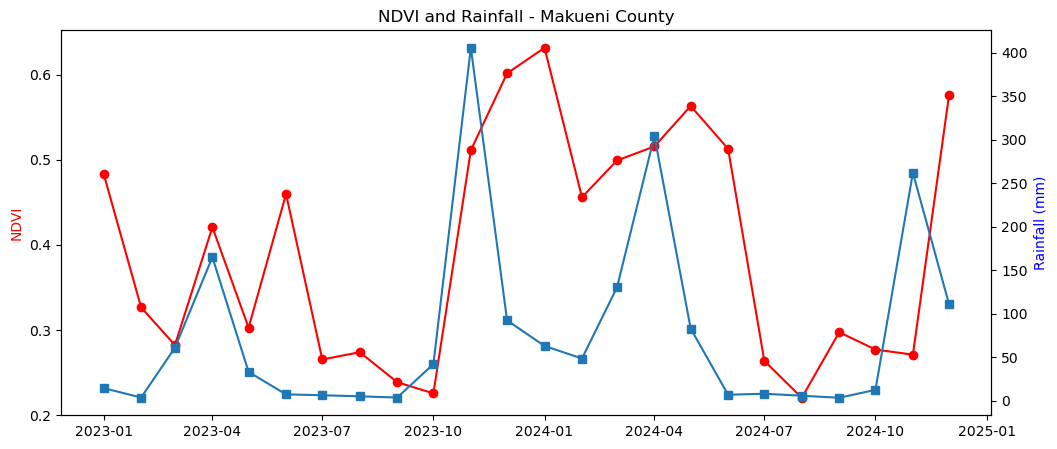

In [17]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(
    combined_df["month"],
    combined_df["mean_ndvi"],
    marker="o",
    label="NDVI",
    color="red"
)

ax1.set_ylabel("NDVI", color="red")

ax2 = ax1.twinx()

ax2.plot(
    combined_df["month"],
    combined_df["rainfall_mm"],
    marker="s",
    label="Rainfall"
)

ax2.set_ylabel("Rainfall (mm)", color="blue")

plt.title("NDVI and Rainfall - Makueni County")

plt.show()

In [9]:
combined_df[
    ["mean_ndvi", "rainfall_mm"]
].corr()

,mean_ndvi,rainfall_mm
mean_ndvi,1.00000,0.35699
rainfall_mm,0.35699,1.00000


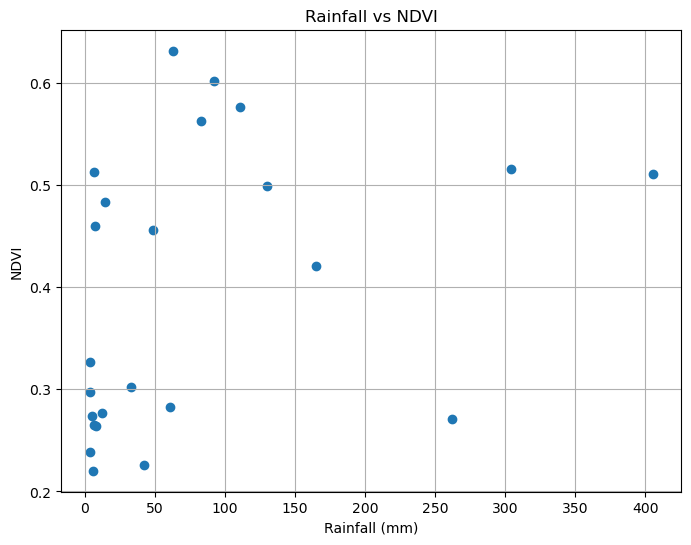

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    combined_df["rainfall_mm"],
    combined_df["mean_ndvi"]
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("NDVI")
plt.title("Rainfall vs NDVI")

plt.grid(True)

plt.show()

In [11]:
combined_df["rainfall_lag1"] = (
    combined_df["rainfall_mm"]
    .shift(1)
)

In [18]:
combined_df[
    ["mean_ndvi", "rainfall_lag1"]
].corr()

,mean_ndvi,rainfall_lag1
mean_ndvi,1.000000,0.693141
rainfall_lag1,0.693141,1.000000


In [19]:
combined_df["rainfall_lag2"] = (
    combined_df["rainfall_mm"]
    .shift(2)
)

In [20]:
combined_df[
    ["mean_ndvi", "rainfall_lag2"]
].corr()

,mean_ndvi,rainfall_lag2
mean_ndvi,1.000000,0.545644
rainfall_lag2,0.545644,1.000000


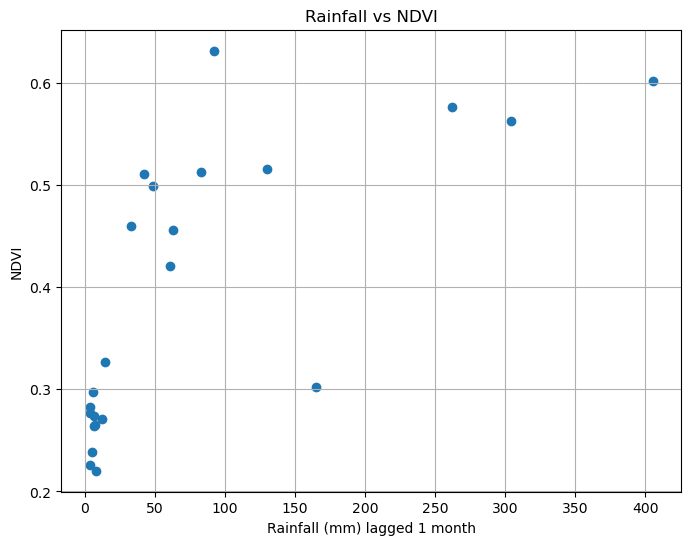

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    combined_df["rainfall_lag1"],
    combined_df["mean_ndvi"]
)

plt.xlabel("Rainfall (mm) lagged 1 month")
plt.ylabel("NDVI")
plt.title("Rainfall vs NDVI")

plt.grid(True)

plt.show()

In [24]:
combined_df.sort_values(
    "rainfall_mm",
    ascending=False
).head()

,month,mean_ndvi,rainfall_mm,rainfall_lag1,rainfall_lag2
10,2023-11-01,0.511180,405.738460,42.187587,3.704895
15,2024-04-01,0.515720,304.464194,130.267565,48.600838
22,2024-11-01,0.271003,262.100963,12.638006,3.470424
3,2023-04-01,0.420843,165.047111,61.026191,3.766772
14,2024-03-01,0.499203,130.267565,48.600838,63.010059
